# Import libs

In [66]:
from __future__ import print_function
import matplotlib.pyplot as plt
%matplotlib inline

import argparse
import os
import cv2
# os.environ['CUDA_VISIBLE_DEVICES'] = '1'

import numpy as np

import torch
import torch.optim

import scipy.io
from scipy.io import savemat
from skimage.metrics import peak_signal_noise_ratio as compare_psnr
from skimage.metrics import structural_similarity as compare_ssim
from models.downsampler import Downsampler
from models.resnet import ResNet
from models.unet import UNet
from models.skip import skip

from utils.sr_utils import *

torch.backends.cudnn.enabled = True
torch.backends.cudnn.benchmark =True
dtype = torch.cuda.FloatTensor

# Load image and baselines

In [67]:
def convert_png_to_mat(input_path, output_path):
    """
    Convert a PNG image to MAT file format suitable for the super-resolution model.
    
    Args:
        input_path (str): Path to the input PNG image
        output_path (str): Path to save the output MAT file
    """
    # Read the image
    img = cv2.imread(input_path, cv2.IMREAD_GRAYSCALE)
    img = img / 255.0
    
    # Resize to create HR, LR, bicubic, and nearest images
    HR = cv2.resize(img, (192, 192))
    LR = cv2.resize(HR, (96, 96))
    bicubic = cv2.resize(LR, (192, 192), interpolation=cv2.INTER_CUBIC)
    nearest = cv2.resize(LR, (192, 192), interpolation=cv2.INTER_NEAREST)
    
    # Create synthetic bands by simulating spectral variations
    def create_bands(image, num_bands=103):
        """
        Create synthetic spectral bands from a grayscale image to simulate
        hyperspectral data, with the original image in the middle of the band range.
        Lower bands are darker, higher bands are brighter with minimal noise and blur.
        """
        bands = []
        h, w = image.shape
        
        # Ensure num_bands is odd so we can place original image in the middle
        if num_bands % 2 == 0:
            num_bands += 1
            
        mid_band = num_bands // 2
        
        # Create bands with different brightness levels
        for i in range(num_bands):
            # For the middle band, use the original image
            if i == mid_band:
                bands.append(image)
                continue
                
            # Calculate intensity adjustment factor
            # Darker for lower bands, brighter for higher bands
            if i < mid_band:
                # For bands before the middle (darker)
                # Map band index to range [0.4, 0.95]
                intensity_factor = 0.4 + (0.55 * i / mid_band)
            else:
                # For bands after the middle (brighter)
                # Map band index to range [1.05, 1.6] with tapering
                relative_pos = (i - mid_band) / (num_bands - mid_band - 1)
                intensity_factor = 1.05 + (0.45 * np.tanh(relative_pos))
                
            # Apply intensity adjustment
            new_band = image.copy() * intensity_factor
            
            # Add minimal spectral characteristics based on position in spectrum
            
            # 1. Apply very light Gaussian blur only to bands far from middle
            # blur_distance = abs(i - mid_band)
            # # Only blur bands that are at least 30% away from the middle
            # if blur_distance > (mid_band * 0.3):
            #     kernel_size = 3  # Consistent minimal blur
            #     new_band = cv2.GaussianBlur(new_band, (kernel_size, kernel_size), 0)
            
            # 2. Add very minimal band-specific noise (90% reduction)
            noise_strength = 0.0005 + (0.0003 * abs(i - mid_band) / mid_band)
            noise = np.random.normal(0, noise_strength, (h, w))
            new_band = np.clip(new_band + noise, 0, 1)
            
            # 3. Apply subtle contrast adjustment based on position
            contrast_factor = 1.0
            if i < mid_band:
                # Lower contrast for bands before middle
                contrast_factor = 0.95 + (0.05 * i / mid_band)
            elif i > mid_band:
                # Higher contrast for bands after middle
                contrast_factor = 1.0 + (0.05 * (i - mid_band) / (num_bands - mid_band))
                
            new_band = np.clip((new_band - 0.5) * contrast_factor + 0.5, 0, 1)
            
            bands.append(new_band)
        
        return np.stack(bands, axis=-1)
    
    # Create multi-band versions of each image
    num_bands = 103  # Using odd number to have middle band as original
    HR = create_bands(HR, num_bands=num_bands)
    LR = create_bands(LR, num_bands=num_bands)
    bicubic = create_bands(bicubic, num_bands=num_bands)
    nearest = create_bands(nearest, num_bands=num_bands)
    
    # Create the output directory if it doesn't exist
    os.makedirs(os.path.dirname(output_path), exist_ok=True)
    
    # Save the processed images to a MAT file
    savemat(output_path, {'HR': HR, 'LR': LR, 'bicubic': bicubic, 'nearest': nearest})
    print(f"Saved preprocessed image for super-resolution model to {output_path}")
    return output_path

Saved preprocessed image for super-resolution model to data/sr/demo_img.mat


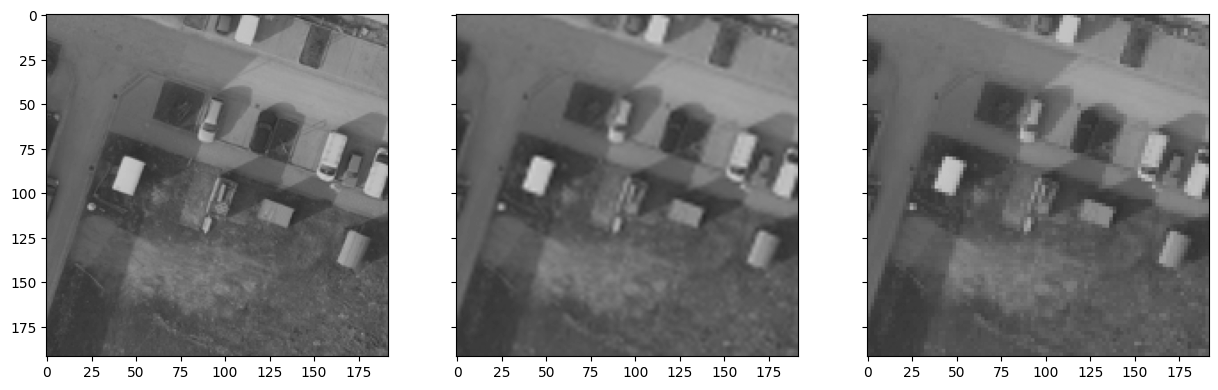

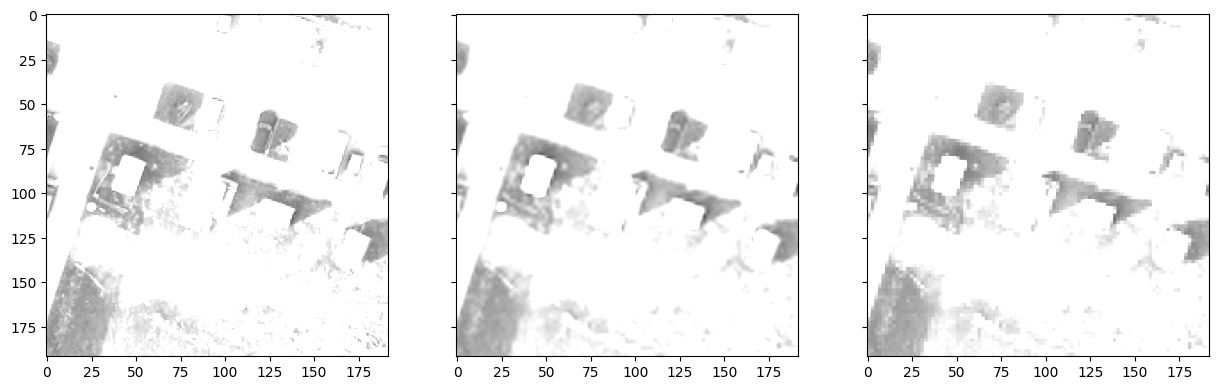

PSNR bicubic: 31.5714   PSNR nearest: 29.7820   SSIM bicubic: 0.9050   SSIM nearest: 0.8841


In [68]:
input_image = "data/input_imgs/demo_img.png"
output_mat = "data/sr/demo_img.mat"
convert_png_to_mat(input_image, output_mat)

file_name  = 'data/sr/sr.mat'

# imgs contains ['HR'] ['LR'] ['bicubic'] ['nearest']
# ensure dimensions [0][1] are divisible by 32 (or 2^depth)!
# imgs = scipy.io.loadmat(file_name)
imgs = scipy.io.loadmat(output_mat)

factor = 2 

#plot band
band = 0

f, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize=(15,15))
ax1.imshow(imgs['HR'][:,:,band], cmap='gray', vmin=0.0, vmax=0.5)
ax2.imshow(imgs['bicubic'][:,:,band], cmap='gray', vmin=0, vmax=0.5) 
ax3.imshow(imgs['nearest'][:,:,band], cmap='gray', vmin=0, vmax=0.5)
plt.show()

#plot band
band = 100

f, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize=(15,15))
ax1.imshow(imgs['HR'][:,:,band], cmap='gray', vmin=0.0, vmax=0.5)
ax2.imshow(imgs['bicubic'][:,:,band], cmap='gray', vmin=0, vmax=0.5) 
ax3.imshow(imgs['nearest'][:,:,band], cmap='gray', vmin=0, vmax=0.5)
plt.show()

print('PSNR bicubic: %.4f   PSNR nearest: %.4f   SSIM bicubic: %.4f   SSIM nearest: %.4f' %  (
    compare_psnr(imgs['HR'], imgs['bicubic']), 
    compare_psnr(imgs['HR'], imgs['nearest']),
    compare_ssim(imgs['HR'], imgs['bicubic'], channel_axis=2, data_range=1.0),
    compare_ssim(imgs['HR'], imgs['nearest'], channel_axis=2, data_range=1.0)))

# Set up parameters and net

In [69]:
input_depth = imgs['HR'].shape[2]

method =    '2D'
pad   =     'reflection'
OPT_OVER =  'net'
KERNEL_TYPE='lanczos2'

show_every = 500
save_every = 2000

LR = 0.01
tv_weight = 0.0

OPTIMIZER = 'adam'

num_iter = 12001
reg_noise_std = 0.01  # try 0 0.03 0.05 0.08

In [70]:
print(imgs['HR'][0].shape)

(192, 103)


In [71]:
net_input = get_noise(input_depth, method, (imgs['HR'].shape[0], imgs['HR'].shape[1])).type(dtype).detach()

net = skip(input_depth, imgs['HR'].shape[2],
           num_channels_down = [128]*5,
           num_channels_up =   [128]*5,
           num_channels_skip =    [4]*5,  
           filter_size_up = 3,filter_size_down = 3,  filter_skip_size=1,
           upsample_mode='bilinear', # downsample_mode='avg',
           need1x1_up=False,
           need_sigmoid=False, need_bias=True, pad=pad, act_fun='LeakyReLU').type(dtype)

# Losses
mse = torch.nn.MSELoss().type(dtype)

img_LR_var = imgs['LR'].transpose(2,0,1)
img_LR_var = torch.from_numpy(img_LR_var).type(dtype)
img_LR_var = img_LR_var[None, :].cuda()

downsampler = Downsampler(n_planes=imgs['HR'].shape[2], factor=factor, kernel_type=KERNEL_TYPE, phase=0.5, preserve_size=True).type(dtype)

# Define closure and optimize

In [72]:
psnr_history = []
net_input_saved = net_input.detach().clone()
noise = net_input.detach().clone()

def closure():
    global i, net_input
    
    if reg_noise_std > 0:
        net_input = net_input_saved + (noise.normal_() * reg_noise_std)

    out_HR = net(net_input)
    out_LR = downsampler(out_HR)

    total_loss = mse(out_LR, img_LR_var) 
    
    if tv_weight > 0:
        total_loss += tv_weight * tv_loss(out_HR)
        
    total_loss.backward()

    # Convert tensors to numpy arrays for metrics calculation
    out_LR_np = out_LR.detach().cpu().squeeze().numpy().transpose(1, 2, 0)
    out_HR_np = out_HR.detach().cpu().squeeze().numpy().transpose(1, 2, 0)
    
    # Calculate PSNR
    psnr_LR = compare_psnr(imgs['LR'].astype(np.float32), out_LR_np)
    psnr_HR = compare_psnr(imgs['HR'].astype(np.float32), out_HR_np)
    
    # Calculate SSIM (multichannel=True for multi-band images)
    ssim_LR = compare_ssim(imgs['LR'].astype(np.float32), out_LR_np, channel_axis=2, data_range=1.0)
    ssim_HR = compare_ssim(imgs['HR'].astype(np.float32), out_HR_np, channel_axis=2, data_range=1.0)
    
    print('Iteration %05d    PSNR_LR %.3f   PSNR_HR %.3f   SSIM_LR %.4f   SSIM_HR %.4f' % 
          (i, psnr_LR, psnr_HR, ssim_LR, ssim_HR), '\r', end='')
                      
    # History - now includes SSIM values
    psnr_history.append([psnr_LR, psnr_HR, ssim_LR, ssim_HR])
    
    if i % show_every == 0:
        band = 50
        out_HR_np = out_HR.detach().cpu().squeeze().numpy().transpose(1,2,0)
        f, (ax1, ax2, ax3) = plt.subplots(1, 3, sharey=True, figsize=(15,15))
        ax1.imshow(imgs['HR'][:,:,band], cmap='gray', vmin=0.0, vmax=0.5)
        ax2.imshow(imgs['bicubic'][:,:,band], cmap='gray', vmin=0.0, vmax=0.5)
        ax3.imshow(np.clip(out_HR_np, 0, 1)[:,:,band], cmap='gray', vmin=0.0, vmax=0.5)
        plt.show()
        
    if i % save_every == 0:
        out_HR_np = out_HR.detach().cpu().squeeze().numpy().transpose(1,2,0)
        scipy.io.savemat("results/result_sr_2D_it%05d.mat" % (i), {'pred':np.clip(out_HR_np, 0, 1)})

    i += 1
    
    return total_loss

Starting optimization with ADAM


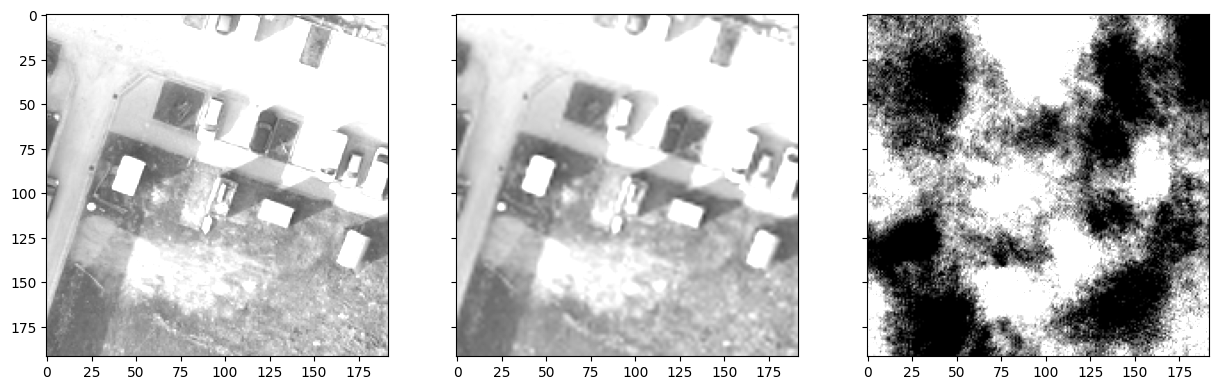

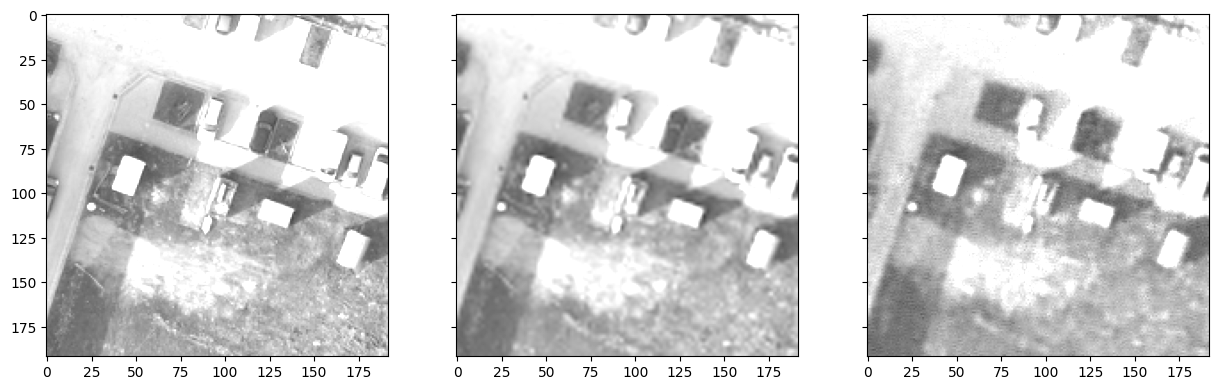

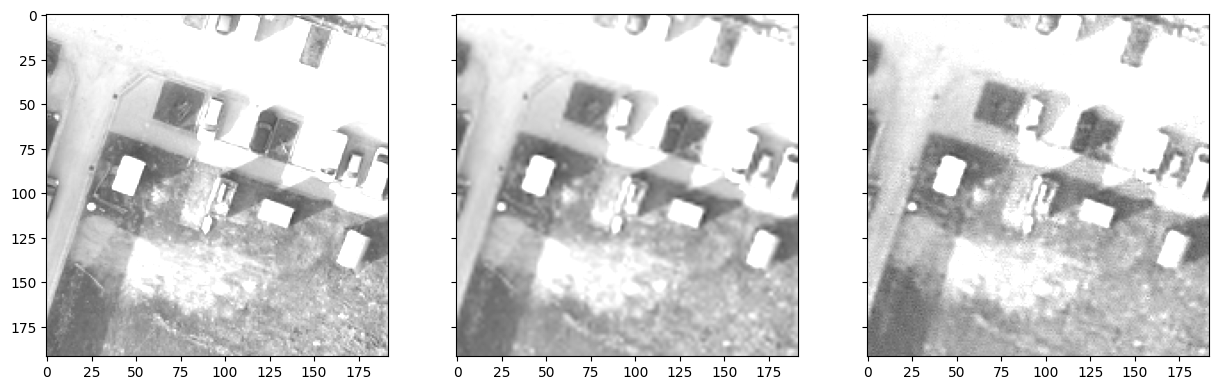

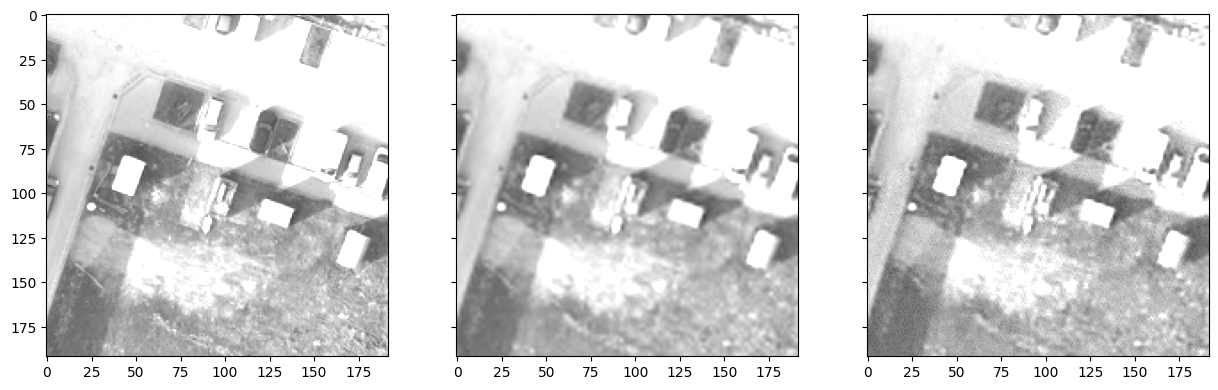

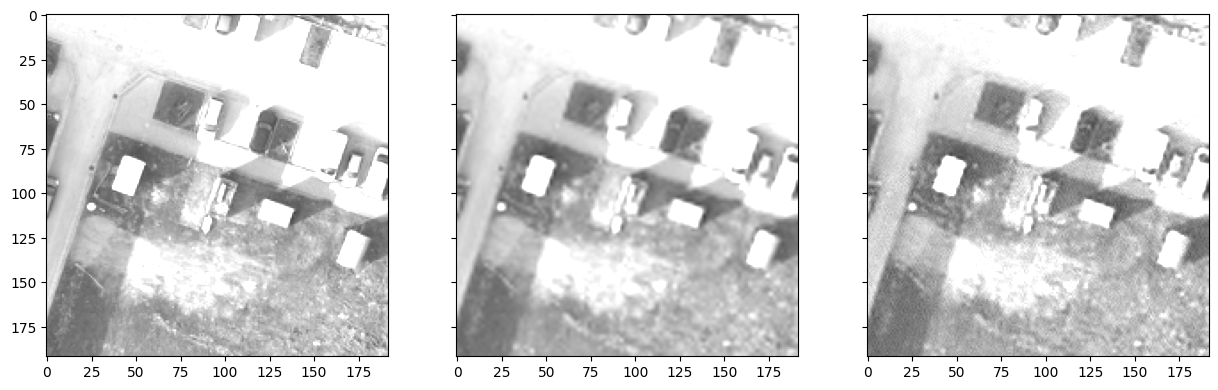

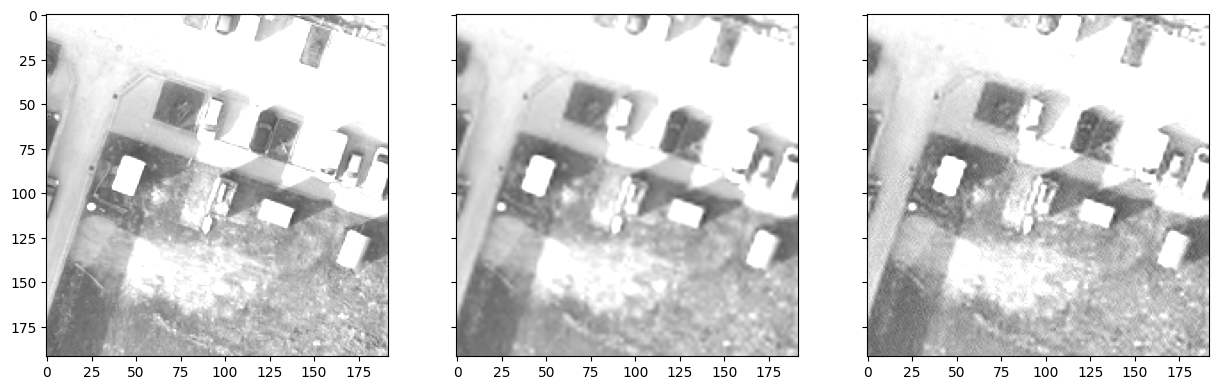

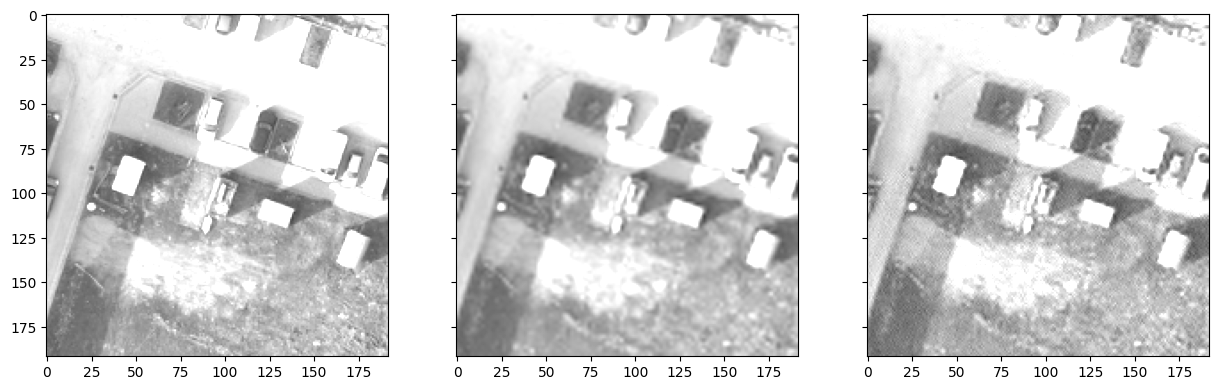

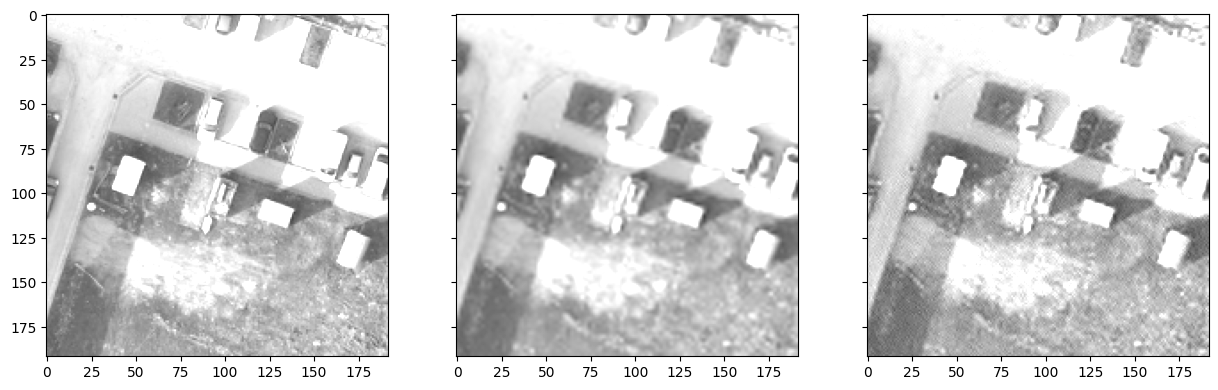

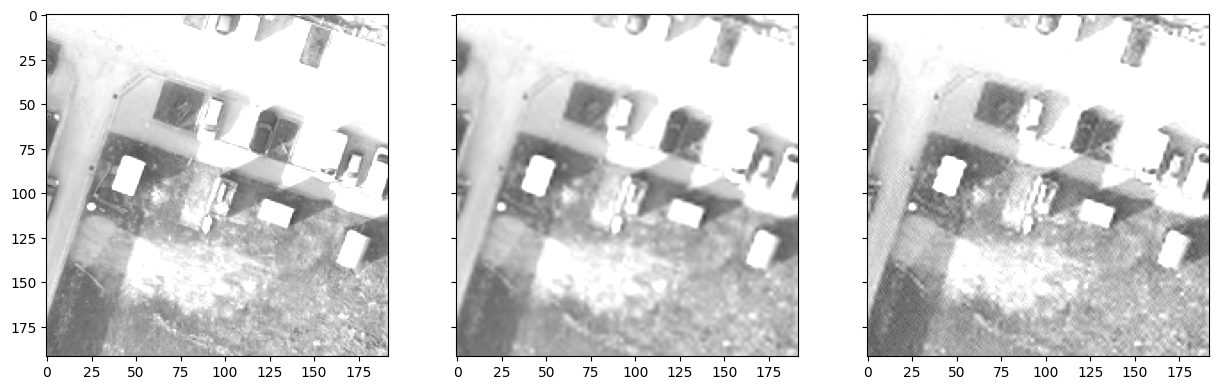

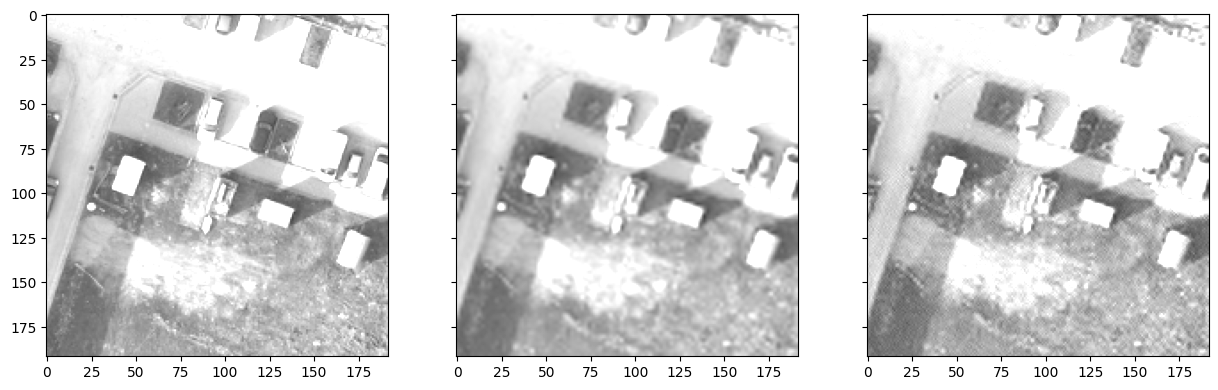

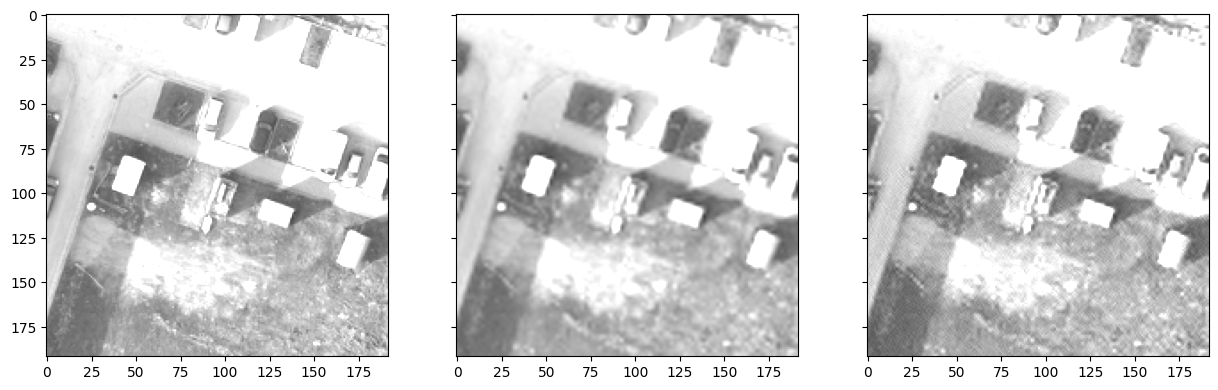

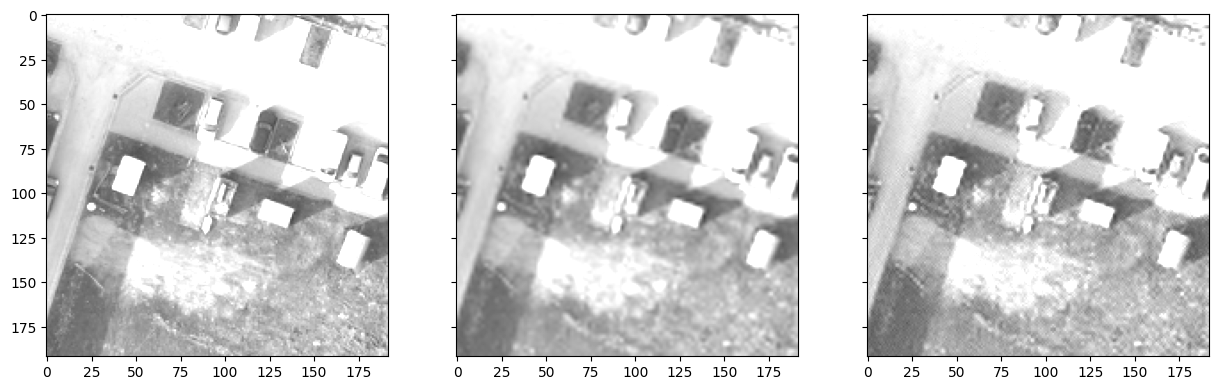

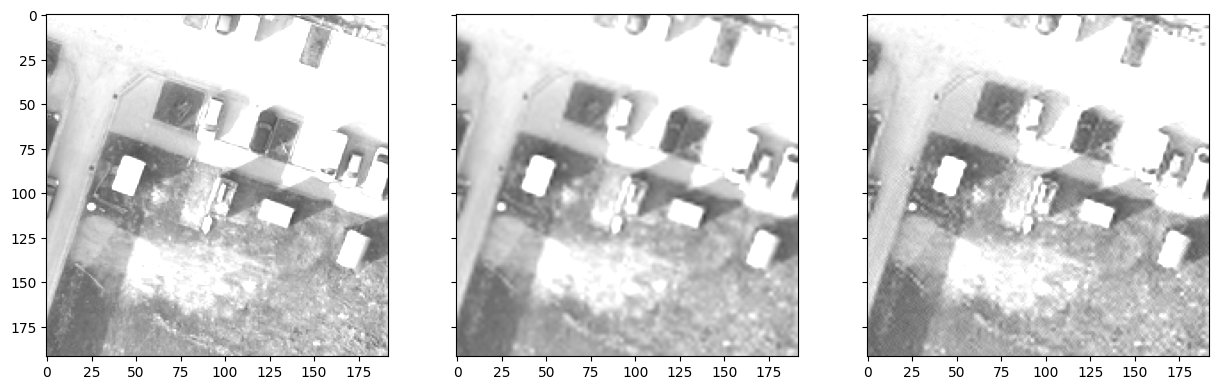

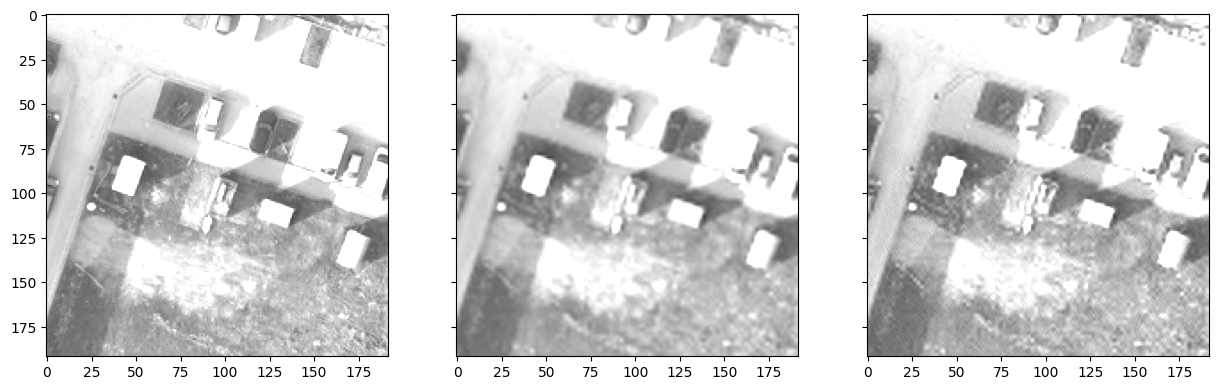

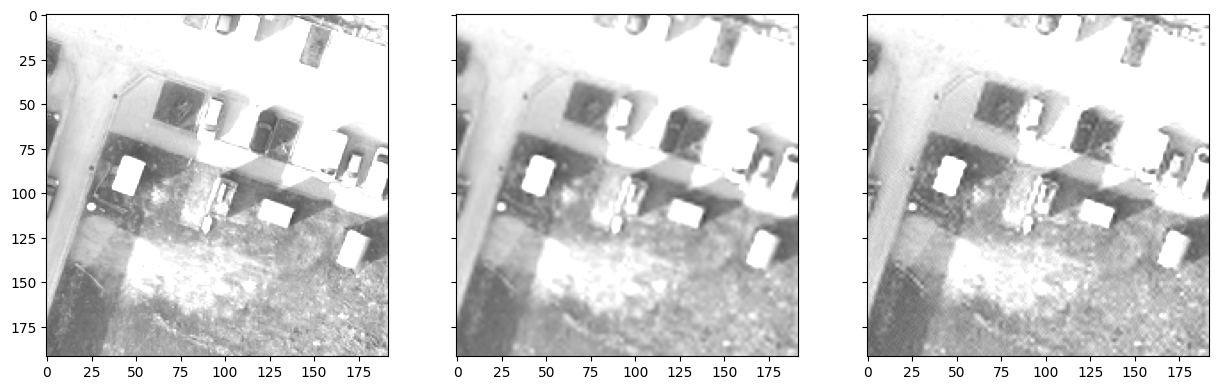

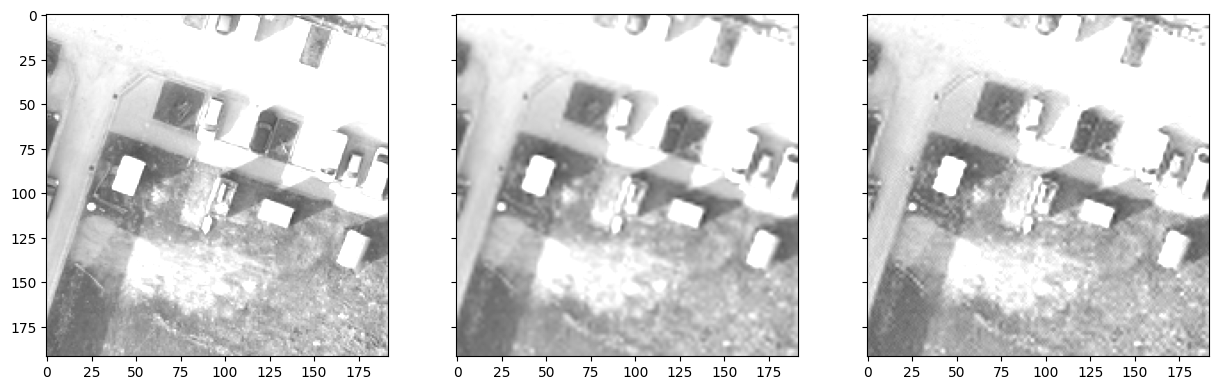

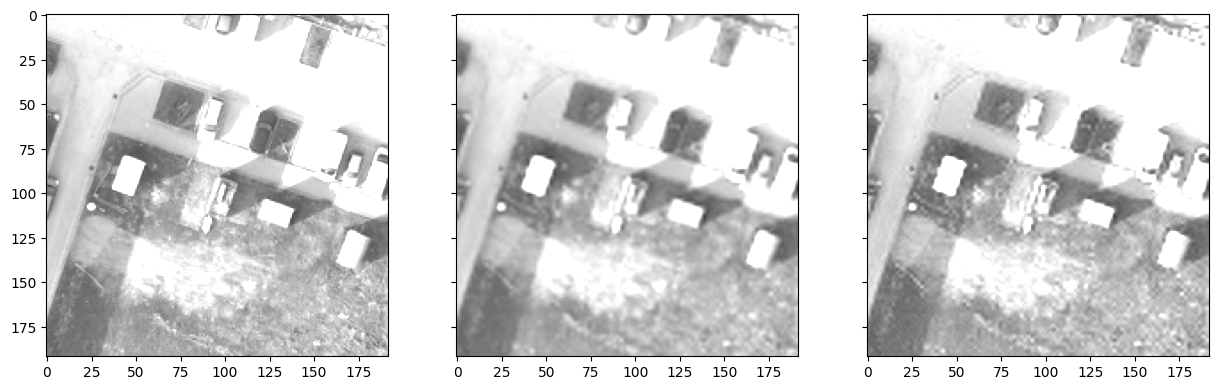

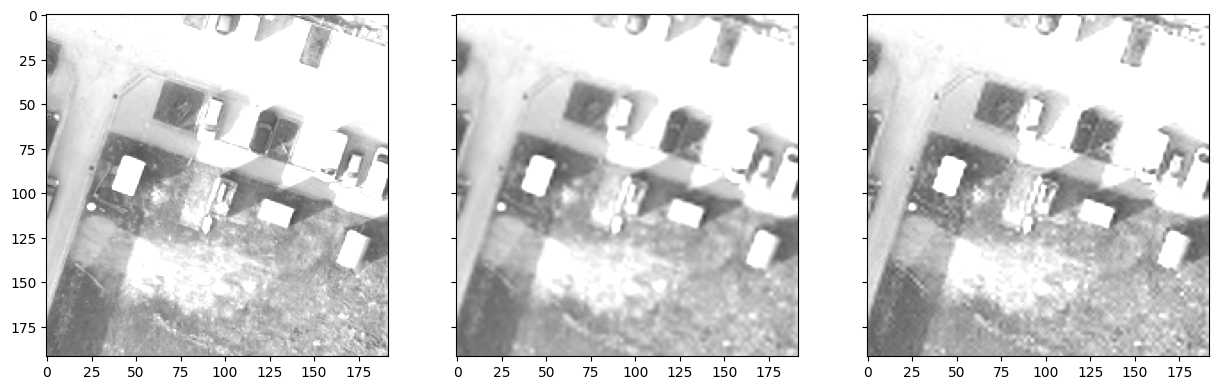

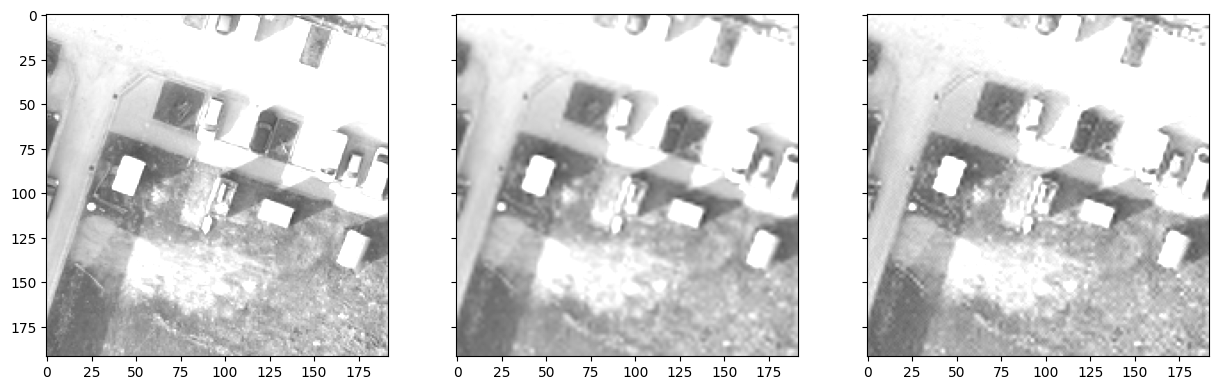

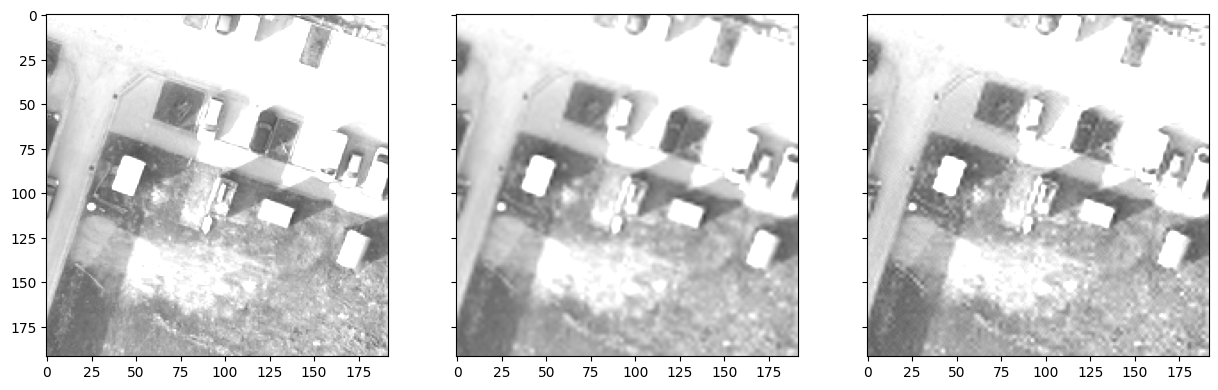

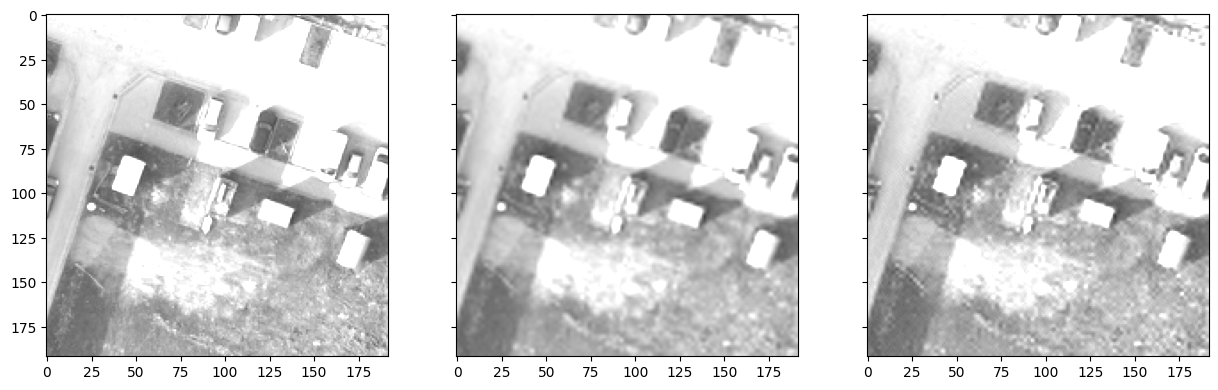

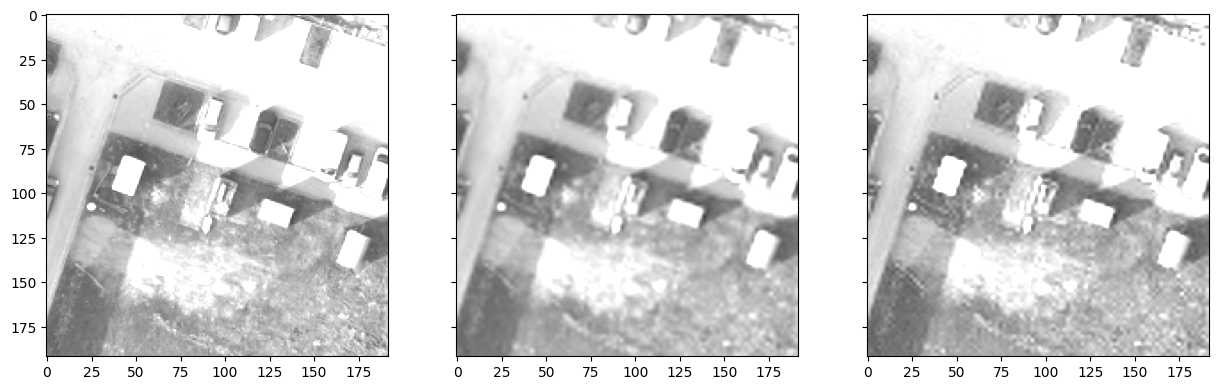

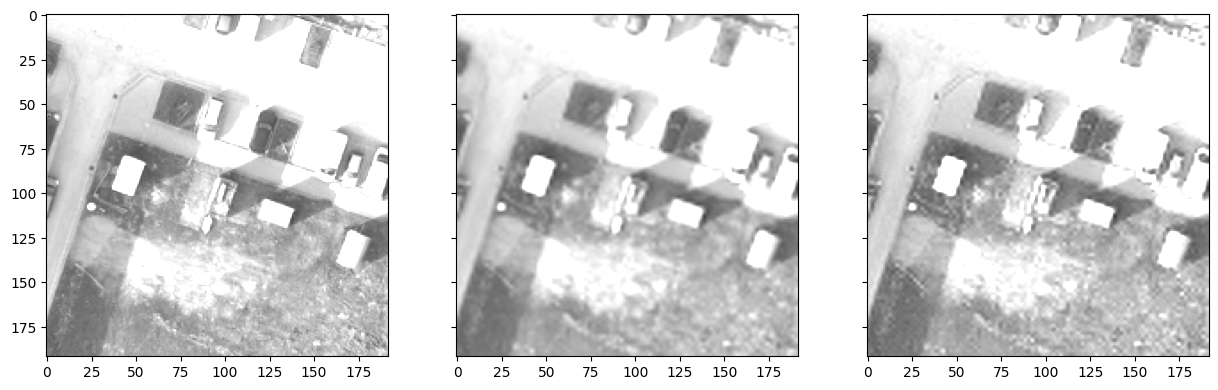

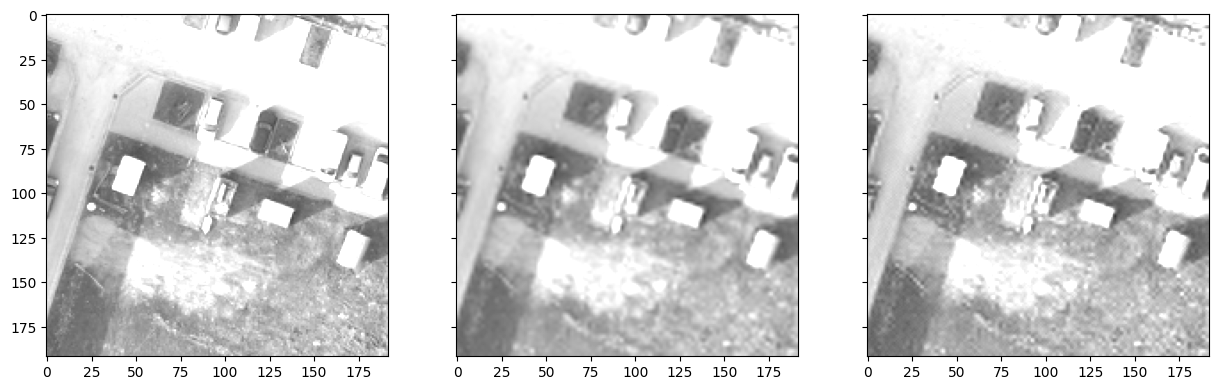

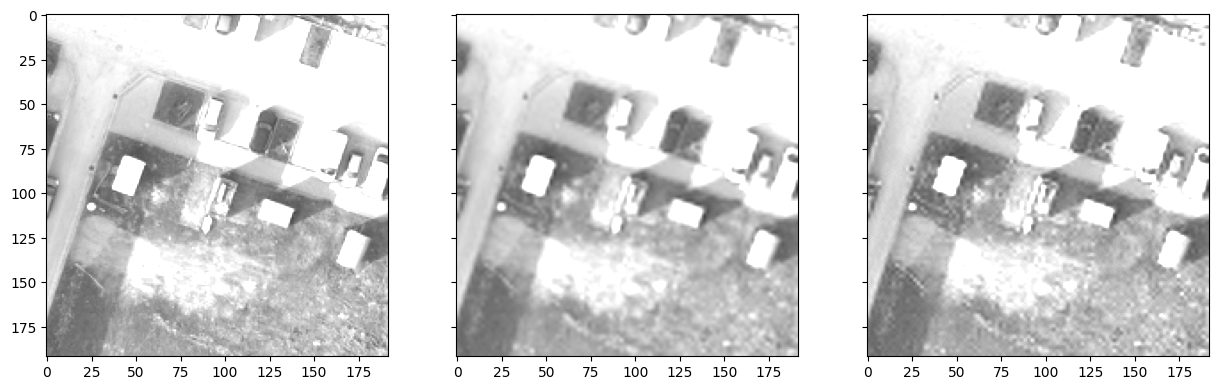

In [73]:
# psnr_history = [] 
# net_input_saved = net_input.detach().clone()
# noise = net_input.detach().clone()

i = 0
p = get_params(OPT_OVER, net, net_input)
optimize(OPTIMIZER, p, closure, LR, num_iter)